# Color Sensor for the Determination of the Ripening Stage of Cherry Tomatoes — pipeline reproduction

**Paper:** Vandeir Aniceto Pinheiro et al., *Color Sensor for the Determination of the Ripening Stage of Cherry Tomatoes*,
Zenodo record 23067950 (DOI [10.5281/zenodo.23067949](https://doi.org/10.5281/zenodo.23067949)).

**Author code & data:** [`vandeiraniceto/color_sensor_tomatoes`](https://github.com/vandeiraniceto/color_sensor_tomatoes) @ commit `2678cf686f305c80d3961b870cda5c0c32612156` (MIT license).

**Scope (partial demonstration, executed):** rerun the author's own preprocessing and clustering scripts verbatim on the raw
triplicated sensor/spectrophotometer readings (130 cherry tomatoes), then port — cell-by-cell, with the author's parameters —
the multivariate sensor-RGB→CIELAB linear calibration and the ATmega328P decision-tree / final-pipeline evaluation from the
three author notebooks. This is a rerun of the author pipeline on all 130 samples; **not** an independent re-validation of
the paper's claims. Hardware construction, RF telemetry and C++ firmware generation are out of scope (the generated C header
constants are used only as reference values).

**実行スコープ（部分再現・実行済み）:** 著者自身の前処理・クラスタリング スクリプトを生データに対してそのまま実行し、
3つの著者ノートブックから較正（センサーRGB→CIELAB線形回帰）と ATmega328P 用決定木評価を同一パラメータで移植実行します。
ハードウェア構築・RFテレメトリ・ファームウェア生成は対象外です。

**Runtime: CPU only** (no GPU needed — the whole pipeline is small-table scikit-learn). Runtime menu → *Select runtime type* → CPU.
**Expected duration:** a few minutes; **downloads:** < 1 MB.

**Provenance note:** the author notebooks embed no separable weight files; all models are trained inside the notebooks from
`dataset.csv`/`dataset_classificado.csv`. This notebook retrains them from the raw data exactly as the authors do.


## 1. Environment setup

**Cell 1 — install the two packages not preinstalled on Colab.** `openpyxl` reads the raw `.xlsx`;
`scikit-image` provides `rgb2lab(..., illuminant=..., observer=...)` used by the author's preprocessing script.
`pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn` are already preinstalled.
**Japanese:** 生データ(xlsx)読込用の `openpyxl` と、色空間変換用の `scikit-image` を追加インストールします。

In [ ]:

%pip install -q openpyxl scikit-image


**Cell 2 — report the actual runtime environment.** Imports the scientific stack used below and
prints Python and library versions so the executed result is traceable to a concrete software stack.
**Japanese:** 実行環境のバージョンを記録します。

In [ ]:

import sys
import numpy as np
import pandas as pd
import sklearn, skimage, matplotlib, seaborn

print("Python:", sys.version)
for m in (np, pd, sklearn, skimage, matplotlib, seaborn):
    print(m.__name__, m.__version__)


Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
skimage 0.25.2
matplotlib 3.10.0
seaborn 0.13.2


## 2. Fetch the pinned author repository inputs

**Cell 3 — resolve the pinned commit tree via the public GitHub API and verify every payload.**
Queries the full tree of `vandeiraniceto/color_sensor_tomatoes` at commit `2678cf686f305c80d3961b870cda5c0c32612156` **once**, then downloads exactly the files this
demonstration needs (raw dataset `DADOS_COLETADO.xlsx`, the two author scripts, the committed derived
CSVs) from `raw.githubusercontent.com`, verifying each **git blob SHA-1 and byte size** against the
pinned tree before use. Anonymous public access only — no credentials. Sample photos are fetched the
same way in Cell 5.
**Japanese:** ピン留めしたコミットのツリーをGitHub APIで1回取得し、必要ファイルだけをraw URLから
ダウンロードし、git blob SHA-1とサイズで検証します。

In [ ]:

import json, hashlib, pathlib, urllib.request

COMMIT = "2678cf686f305c80d3961b870cda5c0c32612156"
REPO = "vandeiraniceto/color_sensor_tomatoes"
RAW = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}"
DEST = pathlib.Path("/content/tomato_src"); DEST.mkdir(exist_ok=True)

REQUIRED = [
    "DADOS_COLETADO.xlsx",
    "1_convertNewDataset.py",
    "2_classificar_maturidade.py",
    "dataset.csv",
    "dataset_classificado.csv",
]

with urllib.request.urlopen(
    f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1", timeout=60
) as r:
    tree = json.loads(r.read())
assert not tree.get("truncated", False), "tree listing truncated"

index = {e["path"]: e for e in tree["tree"]}

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

for rel in REQUIRED:
    meta = index[rel]
    out = DEST / rel
    urllib.request.urlretrieve(f"{RAW}/{rel}", out)
    data = out.read_bytes()
    ok = git_blob_sha(data) == meta["sha"] and len(data) == meta["size"]
    print(("OK      " if ok else "MISMATCH"), rel, len(data), "B", meta["sha"][:12])
    assert ok, rel
print("all pinned payloads verified against commit", COMMIT[:12])


OK       DADOS_COLETADO.xlsx 26109 B 6993b5b7e4ac
OK       1_convertNewDataset.py 2160 B adc4a2343629


OK       2_classificar_maturidade.py 5692 B 46f996604da8
OK       dataset.csv 6015 B f3d1a1737334


OK       dataset_classificado.csv 7056 B 4c6a3bdf2265
all pinned payloads verified against commit 2678cf686f30


**Cell 4 — inspect the raw triplicated dataset.** Loads `DADOS_COLETADO.xlsx` (raw start-of-pipeline
input: 3 sensor RGB readings + 3 spectrophotometer CIELAB readings per fruit, keyed by `ID_FOTO`),
showing its dimensions and columns as directly observed.
**Japanese:** 生データ（各果実につきセンサーRGB 3回・分光測色計CIELAB 3回の測定）の構成を確認します。

In [ ]:

raw = pd.read_excel(DEST / "DADOS_COLETADO.xlsx")
print("shape:", raw.shape)
print("columns:", list(raw.columns))
assert "ID_FOTO" in raw.columns, "README-documented ID_FOTO key missing from raw dataset"
raw.head(3)


shape: (130, 19)
columns: ['ID_FOTO', 'R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'LAB_L1', 'LAB_A1', 'LAB_B1', 'LAB_L2', 'LAB_A2', 'LAB_B2', 'LAB_L3', 'LAB_A3', 'LAB_B3']


,ID_FOTO,R1,G1,B1,R2,G2,B2,R3,G3,B3,LAB_L1,LAB_A1,LAB_B1,LAB_L2,LAB_A2,LAB_B2,LAB_L3,LAB_A3,LAB_B3
0,1,255,167,134,255,167,134,255,167,134,36.13,28.33,21.75,37.04,27.98,21.93,35.56,24.33,20.98
1,2,255,167,134,255,167,134,255,167,134,37.72,26.14,23.86,39.55,24.46,25.96,38.68,26.36,25.73
2,3,255,167,146,255,167,134,255,167,134,39.03,23.43,23.91,37.14,28.48,22.27,40.13,21.38,23.73


**Cell 5 — select one sample photo per maturity stage.** The author's README maps
`photos_tomato/{ID}.jpg` ↔ `ID_FOTO == {ID}`. We take the first Unripe / Medium / Ripe row of the
committed, byte-verified `dataset_classificado.csv` (whose row order the author's scripts preserve),
read the corresponding `ID_FOTO`, download those photos from the pinned commit, and verify their
blob SHA-1 and size.
**Japanese:** READMEの対応規則に従い、Unripe/Medium/Ripe から各1サンプルの写真を同じコミットから取得・検証します。

In [ ]:

dfl_committed = pd.read_csv(DEST / "dataset_classificado.csv")
assert len(raw) == len(dfl_committed), "row alignment with raw xlsx"

photo_ids = {}
for stage in ["Unripe", "Medium", "Ripe"]:
    idx = dfl_committed.index[dfl_committed["Maturity_Stage"] == stage][0]
    photo_ids[stage] = int(raw.loc[idx, "ID_FOTO"])
print("Selected ID_FOTO per stage:", photo_ids)

for stage, pid in photo_ids.items():
    rel = f"photos_tomato/{pid}.jpg"
    meta = index[rel]
    out = DEST / rel
    out.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(f"{RAW}/{rel}", out)
    data = out.read_bytes()
    ok = git_blob_sha(data) == meta["sha"] and len(data) == meta["size"]
    print(("OK      " if ok else "MISMATCH"), rel, len(data), "B")
    assert ok, rel


Selected ID_FOTO per stage: {'Unripe': 84, 'Medium': 73, 'Ripe': 1}


OK       photos_tomato/84.jpg 53934 B


OK       photos_tomato/73.jpg 33014 B


OK       photos_tomato/1.jpg 42338 B


**Cell 6 — input preview: each tomato photo with its real measurements.** For the three selected
samples, displays the author's photograph together with that fruit's **measured** sensor-RGB average
(both raw and CIELAB-converted) and spectrophotometer CIELAB reference, plus a swatch rendered from
the measured sensor RGB. These are measured input data, not model predictions.
**Japanese:** 選んだ3サンプルの写真と、その果実の実測値（センサーRGB平均・CIELAB変換値・分光測色計値）を併記して表示します。

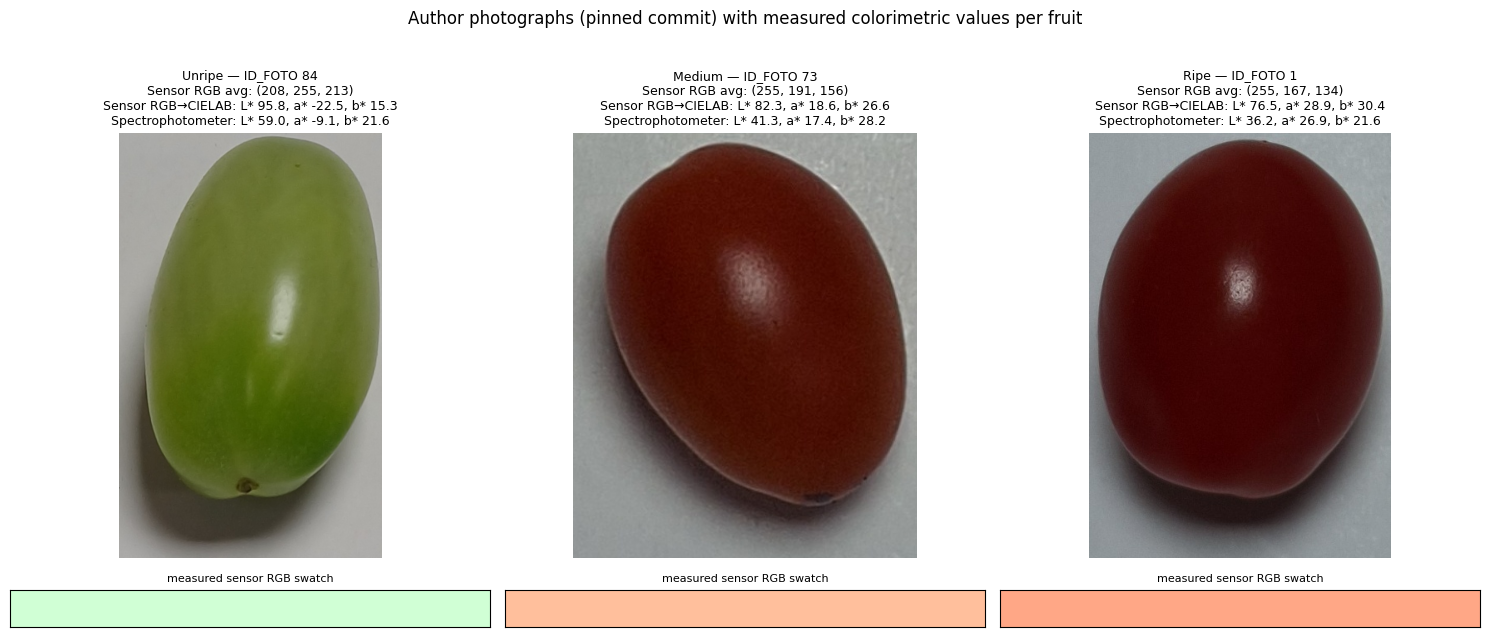

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 3, figsize=(15, 6.2), height_ratios=[4, 0.35])
for col, (stage, pid) in enumerate(photo_ids.items()):
    idx = dfl_committed.index[dfl_committed["Maturity_Stage"] == stage][0]
    row = dfl_committed.loc[idx]
    rrow = raw.loc[idx]
    r_avg = rrow[["R1", "R2", "R3"]].mean()
    g_avg = rrow[["G1", "G2", "G3"]].mean()
    b_avg = rrow[["B1", "B2", "B3"]].mean()

    ax = axes[0, col]
    img = mpimg.imread(DEST / f"photos_tomato/{pid}.jpg")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{stage} — ID_FOTO {pid}\n"
        f"Sensor RGB avg: ({r_avg:.0f}, {g_avg:.0f}, {b_avg:.0f})\n"
        f"Sensor RGB→CIELAB: L* {row['L_RGB_TO_LAB']:.1f}, a* {row['A_RGB_TO_LAB']:.1f}, b* {row['B_RGB_TO_LAB']:.1f}\n"
        f"Spectrophotometer: L* {row['L_LAB_AVG']:.1f}, a* {row['A_LAB_AVG']:.1f}, b* {row['B_LAB_AVG']:.1f}",
        fontsize=9)

    sw = axes[1, col]
    sw.set_title("measured sensor RGB swatch", fontsize=8)
    sw.add_patch(Rectangle((0, 0), 1, 1, color=(r_avg / 255, g_avg / 255, b_avg / 255)))
    sw.set_xlim(0, 1); sw.set_ylim(0, 1)
    sw.set_xticks([]); sw.set_yticks([])
fig.suptitle("Author photographs (pinned commit) with measured colorimetric values per fruit", y=1.02)
plt.tight_layout()
plt.show()


## 3. Run the author's preprocessing & clustering scripts verbatim

**Cell 7 — execute `1_convertNewDataset.py` exactly as the README documents.** The script averages the
triplicated readings and converts sensor RGB to CIELAB (D65/2°) with `skimage.color.rgb2lab`, writing
`dataset.csv`. We run the byte-verified script in a scratch directory and verify the regenerated
`dataset.csv` against the committed blob SHA-1 (expected: byte-identical rerun).
**Japanese:** 著者の前処理スクリプトをそのまま実行し、再生成した `dataset.csv` がコミット済みファイルと
バイト一致することを確認します。

In [ ]:

import shutil, subprocess

SCRATCH = pathlib.Path("/content/tomato_scratch")
SCRATCH.mkdir(exist_ok=True)
for f in ["DADOS_COLETADO.xlsx", "1_convertNewDataset.py", "2_classificar_maturidade.py"]:
    shutil.copy(DEST / f, SCRATCH / f)

r = subprocess.run(["python", "1_convertNewDataset.py"], cwd=SCRATCH,
                   capture_output=True, text=True, timeout=600)
print(r.stdout)
assert r.returncode == 0, r.stderr

regen = git_blob_sha((SCRATCH / "dataset.csv").read_bytes())
committed = git_blob_sha((DEST / "dataset.csv").read_bytes())
print(f"dataset.csv regenerated {regen[:12]} vs committed {committed[:12]}  match={regen == committed}")
assert regen == committed


Processamento concluído!
Arquivo: dataset.csv

dataset.csv regenerated f3d1a1737334 vs committed f3d1a1737334  match=True


**Cell 8 — show the regenerated averaged dataset.** `dataset.csv` holds, per fruit, the reference
CIELAB (`*_LAB_AVG`, spectrophotometer) and the sensor RGB converted to CIELAB (`*_RGB_TO_LAB`).
**Japanese:** 再生成された dataset.csv（分光測色計値とセンサーRGBのCIELAB変換値）を表示します。

In [ ]:

df = pd.read_csv(SCRATCH / "dataset.csv")
print("shape:", df.shape)
df.head()


shape: (130, 6)


,L_LAB_AVG,A_LAB_AVG,B_LAB_AVG,L_RGB_TO_LAB,A_RGB_TO_LAB,B_RGB_TO_LAB
0,36.2433,26.8800,21.5533,76.4504,28.9053,30.4335
1,38.6500,25.6533,25.1833,76.4504,28.9053,30.4335
2,38.7667,24.4300,23.3033,76.5195,29.2883,28.3849
3,37.2567,25.8767,22.5867,76.4504,28.9053,30.4335
4,36.0200,24.2567,21.0633,76.4504,28.9053,30.4335


**Cell 9 — execute `2_classificar_maturidade.py` verbatim.** The script standardizes the reference
CIELAB columns, runs K-Means (k=3, `random_state=42`, `n_init=20`), orders the clusters by mean a*
(green → intermediate → red) into `Unripe`/`Medium`/`Ripe`, and writes `dataset_classificado.csv`.
We again verify the regenerated file against the committed blob SHA-1.
**Japanese:** 著者のクラスタリング スクリプトを実行し、クラス標識付きCSVがコミット済みとバイト一致することを確認します。

In [ ]:

r = subprocess.run(["python", "2_classificar_maturidade.py"], cwd=SCRATCH,
                   capture_output=True, text=True, timeout=600)
print(r.stdout)
assert r.returncode == 0, r.stderr

regen2 = git_blob_sha((SCRATCH / "dataset_classificado.csv").read_bytes())
committed2 = git_blob_sha((DEST / "dataset_classificado.csv").read_bytes())
print(f"dataset_classificado.csv regenerated {regen2[:12]} vs committed {committed2[:12]}  match={regen2 == committed2}")
assert regen2 == committed2

dfl = pd.read_csv(SCRATCH / "dataset_classificado.csv")
print(dfl["Maturity_Stage"].value_counts())


Classification complete. Updated CSV saved to: dataset_classificado.csv

--- Summary Statistics by Maturity Stage ---
               L_LAB_AVG              A_LAB_AVG              B_LAB_AVG             
                   count   mean   std     count   mean   std     count   mean   std
Maturity_Stage                                                                     
Medium                27  47.51  4.28        27   7.23  6.55        27  29.81  1.94
Ripe                  78  37.96  1.53        78  23.18  2.43        78  23.05  1.87
Unripe                25  56.18  4.64        25  -6.42  4.18        25  24.23  2.83

All individual figures saved successfully in PNG (300 DPI) and PDF vector formats in 'figures/' folder.

dataset_classificado.csv regenerated 4c6a3bdf2265 vs committed 4c6a3bdf2265  match=True
Maturity_Stage
Ripe      78
Medium    27
Unripe    25
Name: count, dtype: int64


## 4. Colorimetric calibration — faithful port of `tomato_linear_regression_calibration_atmega.ipynb`

The following cells copy the author's calibration notebook code (pinned commit, code cells) with
unchanged parameters; only file paths and display plumbing are adapted for this notebook.
**Japanese:** 以下は著者の較正ノートブックのコードをパラメータ変更なしで移植したものです。

**Cell 10 — pre-calibration color error.** Euclidean ΔE between the raw sensor RGB→CIELAB values and
the spectrophotometer reference, per fruit (author code cell, unchanged).
**Japanese:** 較正前の色差 ΔE（センサーRGB→CIELAB と 分光測色計値のユークリッド距離）を計算します。

In [ ]:

delta_E_raw = np.sqrt(
    (df['L_RGB_TO_LAB'] - df['L_LAB_AVG'])**2 +
    (df['A_RGB_TO_LAB'] - df['A_LAB_AVG'])**2 +
    (df['B_RGB_TO_LAB'] - df['B_LAB_AVG'])**2
)

print(f"Pre-Calibration Mean Delta E: {delta_E_raw.mean():.2f} +/- {delta_E_raw.std():.2f}")
print(f"Pre-Calibration Max Delta E:  {delta_E_raw.max():.2f}")


Pre-Calibration Mean Delta E: 41.40 +/- 3.59
Pre-Calibration Max Delta E:  55.83


**Cell 11 — train the multivariate linear calibration with out-of-fold cross-validation.** Author's
setup, unchanged: for each target coordinate (L*, a*, b*) a `LinearRegression` maps the three
sensor RGB→CIELAB predictors to the spectrophotometer reference; `KFold(5, shuffle=True,
random_state=42)` with `cross_val_predict` gives out-of-fold predictions; a final model is fit on
the full data. Metrics are computed on the out-of-fold predictions.
**Japanese:** 著者と同一の設定（5-fold CV・各座標ごとの線形回帰）で較正モデルを学習します。

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

x_cols = ['L_RGB_TO_LAB', 'A_RGB_TO_LAB', 'B_RGB_TO_LAB']
y_cols = ['L_LAB_AVG', 'A_LAB_AVG', 'B_LAB_AVG']
X = df[x_cols]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {}
y_preds_cv = pd.DataFrame(index=df.index, columns=y_cols, dtype=float)

for target in y_cols:
    lr = LinearRegression()
    y_true = df[target]
    pred_cv = cross_val_predict(lr, X, y_true, cv=kf)
    y_preds_cv[target] = pred_cv
    lr.fit(X, y_true)
    models[target] = lr
    print(f"{target}: CV R2={r2_score(y_true, pred_cv):.4f}  "
          f"CV RMSE={np.sqrt(mean_squared_error(y_true, pred_cv)):.4f}  "
          f"CV MAE={mean_absolute_error(y_true, pred_cv):.4f}")


L_LAB_AVG: CV R2=0.8271  CV RMSE=3.2655  CV MAE=2.5100
A_LAB_AVG: CV R2=0.9421  CV RMSE=3.0000  CV MAE=2.2922
B_LAB_AVG: CV R2=0.3279  CV RMSE=2.7688  CV MAE=2.1213


**Cell 12 — check the trained coefficients against the author's published embedded constants.**
The calibration notebook generates `tomato_color_calibration_atmega.h` with the fitted intercepts and
coefficients as float literals — the author's own recorded training result. This comparison is
diagnostic: if the retrained coefficients differ materially, the header was produced under a different
library version or pipeline state than the current pinned rerun. Cell 18 uses the author's embedded
constants verbatim either way, exactly as the author's final notebook does.
**Japanese:** 再学習した回帰係数を、著者が生成したCヘッダの係数と比較します（診断的比較）。Cell 18 では
著者の最終ノートブックと同様に、埋め込み定数をそのまま使用します。

In [ ]:

AUTHOR_EMBEDDED = {
    'L_LAB_AVG': {'intercept': 24.560113, 'coefs': [0.289091, -0.226072, -0.096143]},
    'A_LAB_AVG': {'intercept': 16.348766, 'coefs': [-0.170302, 0.580015, 0.150526]},
    'B_LAB_AVG': {'intercept': -36.516047, 'coefs': [0.617215, 0.188744, 0.246772]},
}
rows = []
for target in y_cols:
    lr = models[target]
    ref = AUTHOR_EMBEDDED[target]
    rows.append({
        'Target': target,
        'Retrained intercept': round(lr.intercept_, 6),
        'Author C-header intercept': ref['intercept'],
        'Retrained coefs (L,a,b)': [round(c, 6) for c in lr.coef_],
        'Author C-header coefs': ref['coefs'],
    })
pd.DataFrame(rows)


,Target,Retrained intercept,Author C-header intercept,"Retrained coefs (L,a,b)",Author C-header coefs
0,L_LAB_AVG,-0.033050,24.560113,"[0.588765, -0.109235, -0.159562]","[0.289091, -0.226072, -0.096143]"
1,A_LAB_AVG,14.122394,16.348766,"[-0.130818, 0.606436, 0.096238]","[-0.170302, 0.580015, 0.150526]"
2,B_LAB_AVG,-32.394579,-36.516047,"[0.550072, 0.14873, 0.322169]","[0.617215, 0.188744, 0.246772]"


**Cell 13 — post-calibration error and reduction.** ΔE computed from the out-of-fold calibrated
predictions; the reduction percentage is the quantity the paper's abstract reports as 89.6%.
**Japanese:** 較正後のΔE（out-of-fold予測）と、論文が89.6%と報告する誤差削減率を計算します。

In [ ]:

delta_E_calibrated = np.sqrt(
    (y_preds_cv['L_LAB_AVG'] - df['L_LAB_AVG'])**2 +
    (y_preds_cv['A_LAB_AVG'] - df['A_LAB_AVG'])**2 +
    (y_preds_cv['B_LAB_AVG'] - df['B_LAB_AVG'])**2
)

print(f"Post-Calibration Mean Delta E: {delta_E_calibrated.mean():.2f} +/- {delta_E_calibrated.std():.2f}")
print(f"Post-Calibration Max Delta E:  {delta_E_calibrated.max():.2f}")
print(f"Total Error Reduction:          {((delta_E_raw.mean() - delta_E_calibrated.mean()) / delta_E_raw.mean()) * 100:.1f}%")


Post-Calibration Mean Delta E: 4.49 +/- 2.68
Post-Calibration Max Delta E:  14.46
Total Error Reduction:          89.1%


**Cell 14 — calibration figures (author cell, unchanged).** Top: observed vs predicted scatter for
L*, a*, b* with the 1:1 line. Bottom: the ΔE distribution before/after calibration with the ΔE=3
perception threshold. The rendered PNGs are this notebook's own outputs.
**Japanese:** 較正の観測値 vs 予測値散布図とΔE分布を描画します（著者セルのまま）。

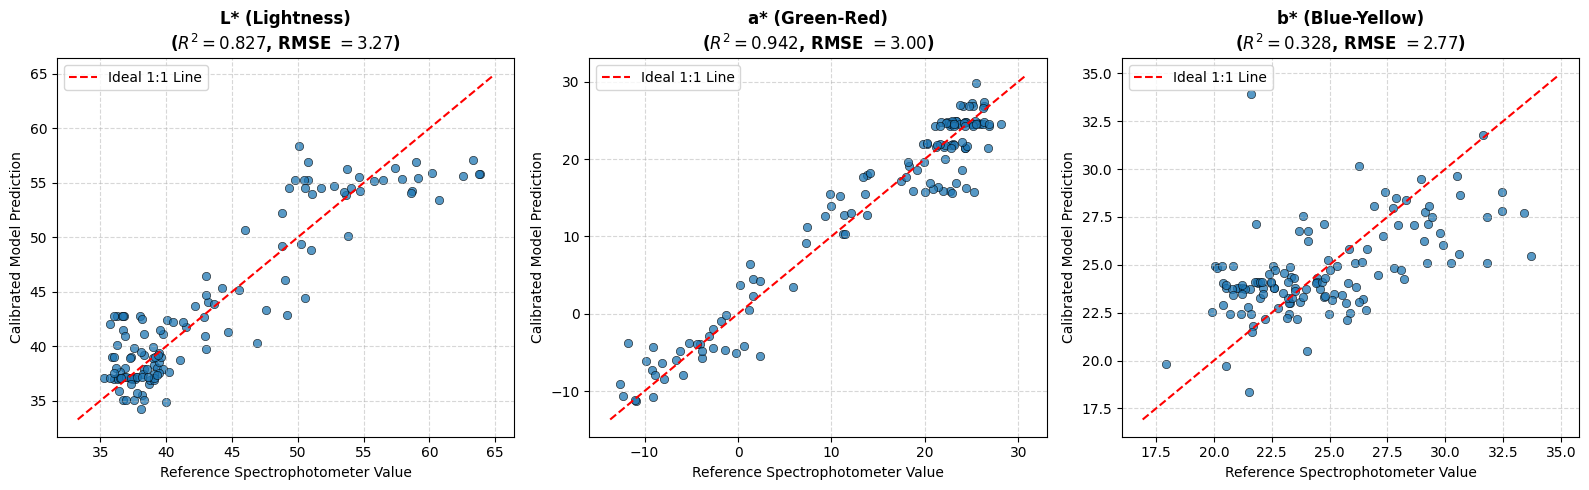

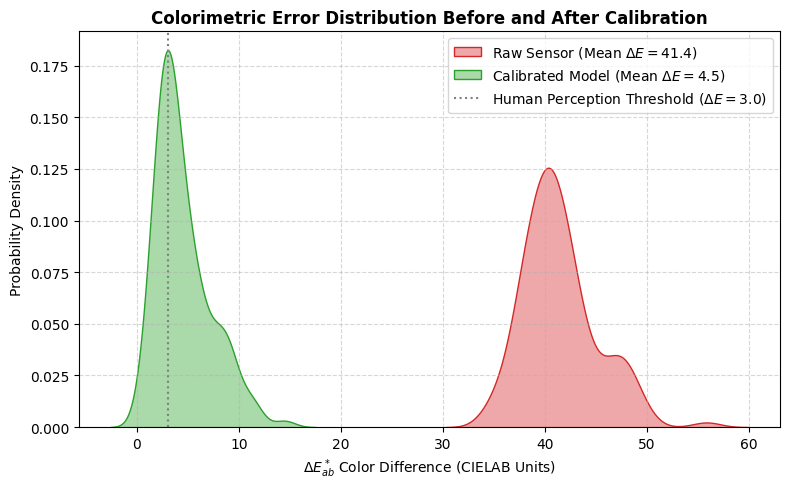

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ['L* (Lightness)', 'a* (Green-Red)', 'b* (Blue-Yellow)']

for i, (target, title) in enumerate(zip(y_cols, labels)):
    ax = axes[i]
    y_true = df[target]
    y_pred = y_preds_cv[target].astype(float)
    ax.scatter(y_true, y_pred, alpha=0.75, edgecolors='k', linewidth=0.5, color='#1f77b4')
    lims = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, '--r', linewidth=1.5, label='Ideal 1:1 Line')
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f"{title}\n($R^2 = {r2:.3f}$, RMSE $= {rmse:.2f}$)", fontweight='bold')
    ax.set_xlabel('Reference Spectrophotometer Value')
    ax.set_ylabel('Calibrated Model Prediction')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(delta_E_raw, fill=True, color='#d62728', label=f'Raw Sensor (Mean $\\Delta E = {delta_E_raw.mean():.1f}$)', alpha=0.4)
sns.kdeplot(delta_E_calibrated, fill=True, color='#2ca02c', label=f'Calibrated Model (Mean $\\Delta E = {delta_E_calibrated.mean():.1f}$)', alpha=0.4)
plt.axvline(3.0, color='gray', linestyle=':', label='Human Perception Threshold ($\\Delta E = 3.0$)')
plt.xlabel('$\\Delta E_{ab}^*$ Color Difference (CIELAB Units)')
plt.ylabel('Probability Density')
plt.title('Colorimetric Error Distribution Before and After Calibration', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## 5. Maturity classification — faithful port of `tomato_maturity_decision_tree_atmega.ipynb`

Author's code cells again, parameters unchanged. Note the "USDA ripening stage" labels are the
K-Means-derived `Unripe`/`Medium`/`Ripe` ground truth from script 2 (the paper's abstract-level stage
names); no independent human grading exists in the available material.
**Japanese:** 決定木の部分も著者コードのまま移植します。クラス標識は a* 順の K-Means 由来のものです。

**Cell 15 — model selection grid.** Stratified 5-fold CV accuracy for gini/entropy criteria at
depths 2–4 (author's grid, unchanged).
**Japanese:** gini/entropy × 深さ2–4 の層化5-fold CV精度を著者のグリッドのまま比較します。

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

X_tree = dfl[['L_LAB_AVG', 'A_LAB_AVG', 'B_LAB_AVG']]
y_tree = dfl['Maturity_Stage']
cv_tree = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for criterion in ['gini', 'entropy']:
    for depth in [2, 3, 4]:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        scores = cross_val_score(clf, X_tree, y_tree, cv=cv_tree, scoring='accuracy')
        results.append({'Criterion': criterion, 'Max Depth': depth,
                        'Mean Accuracy': round(scores.mean(), 4), 'Std Dev': round(scores.std(), 4)})
pd.DataFrame(results)


,Criterion,Max Depth,Mean Accuracy,Std Dev
0,gini,2,0.9154,0.0288
1,gini,3,0.9615,0.0344
2,gini,4,0.9615,0.0243
3,entropy,2,0.9154,0.0288
4,entropy,3,0.9615,0.0344
5,entropy,4,0.9538,0.0288


**Cell 16 — fit the author's production tree and evaluate out-of-fold.** The author chose
`entropy, max_depth=3, random_state=42`; out-of-fold predictions via `cross_val_predict` give the
classification report and confusion matrix. The accuracy is the quantity the paper's abstract reports
as 93.08%. **One documented adaptation:** the author's `classification_report` call omits `labels=`,
which reassigns class names alphabetically (`Medium, Ripe, Unripe`) while the matrix keeps the intended
order; we pass `labels=class_labels` so per-class metrics are named correctly. The confusion matrix
already used explicit labels in the author's code.
**Japanese:** 著者が選んだ production 木（entropy, 深さ3）を学習し、out-of-fold 予測で精度・混合行列を評価します。
唯一の適応：著者コードの `classification_report` は `labels=` を省略しておりクラス名がアルファベット順に
ずれるため、`labels=class_labels` を明示して正しく対応付けます。

=== OUT-OF-FOLD CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Unripe     0.9600    0.9600    0.9600        25
      Medium     0.9231    0.8889    0.9057        27
        Ripe     0.9747    0.9872    0.9809        78

    accuracy                         0.9615       130
   macro avg     0.9526    0.9454    0.9489       130
weighted avg     0.9611    0.9615    0.9612       130

Out-of-fold accuracy: 96.15%


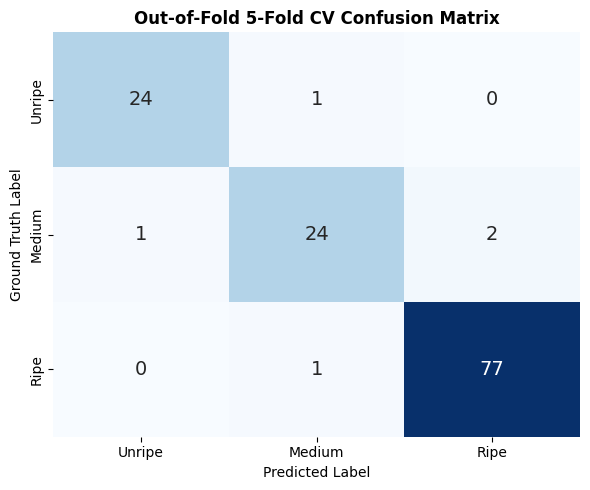

In [ ]:

dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_model.fit(X_tree, y_tree)
y_cv_pred = cross_val_predict(dt_model, X_tree, y_tree, cv=cv_tree)

class_labels = ['Unripe', 'Medium', 'Ripe']
print("=== OUT-OF-FOLD CLASSIFICATION REPORT ===")
print(classification_report(y_tree, y_cv_pred, labels=class_labels, target_names=class_labels, digits=4))
print("Out-of-fold accuracy: %.2f%%" % (accuracy_score(y_tree, y_cv_pred) * 100))

cm = confusion_matrix(y_tree, y_cv_pred, labels=class_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth Label')
plt.title('Out-of-Fold 5-Fold CV Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


**Cell 17 — the induced decision rules and tree diagram.** `export_text` shows the minimal boolean
logic; `plot_tree` renders the depth-3 tree. The author's generated C header implements the same
thresholds (`L*<=40.79 → Ripe`, `a*<=-1.58 → Unripe`, else `b*>24.84 → Medium` else `Unripe`).
**Japanese:** 学習された決定規則と木図を表示します。生成済みCヘッダと同じしきい値に対応します。

|--- A_LAB_AVG <= 18.26
|   |--- B_LAB_AVG <= 26.33
|   |   |--- A_LAB_AVG <= 7.99
|   |   |   |--- class: Unripe
|   |   |--- A_LAB_AVG >  7.99
|   |   |   |--- class: Ripe
|   |--- B_LAB_AVG >  26.33
|   |   |--- A_LAB_AVG <= -2.25
|   |   |   |--- class: Unripe
|   |   |--- A_LAB_AVG >  -2.25
|   |   |   |--- class: Medium
|--- A_LAB_AVG >  18.26
|   |--- class: Ripe



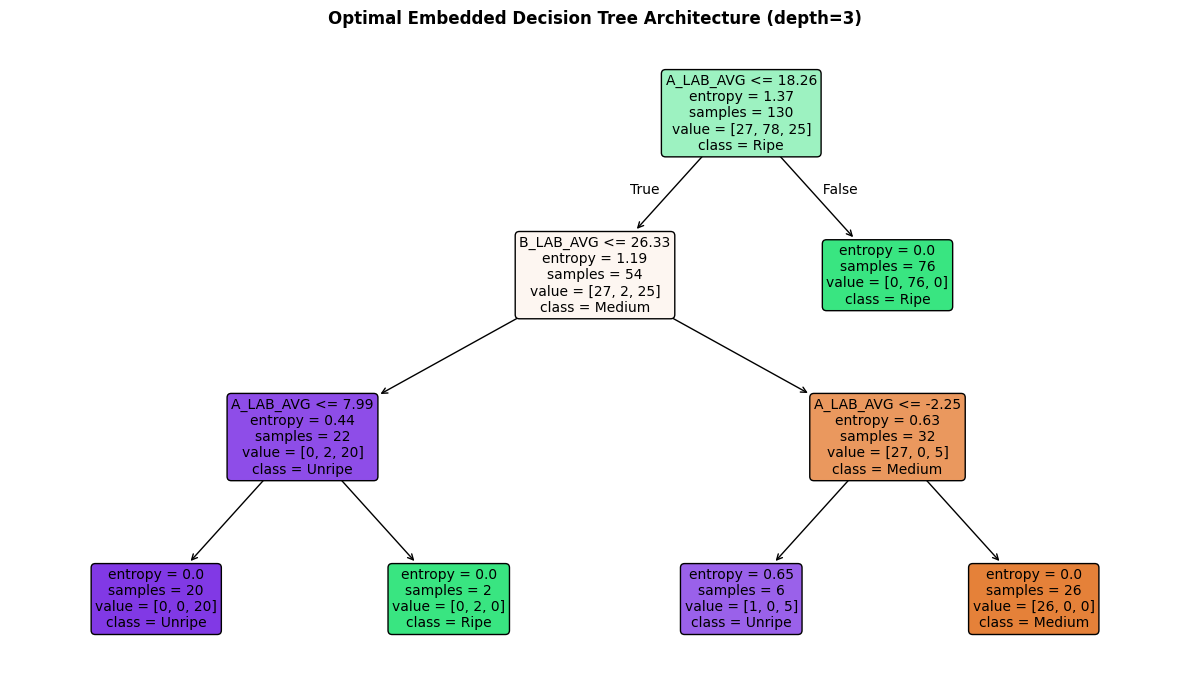

In [ ]:

from sklearn.tree import export_text, plot_tree

print(export_text(dt_model, feature_names=['L_LAB_AVG', 'A_LAB_AVG', 'B_LAB_AVG']))

plt.figure(figsize=(12, 7))
plot_tree(dt_model, feature_names=['L_LAB_AVG', 'A_LAB_AVG', 'B_LAB_AVG'],
          class_names=dt_model.classes_, filled=True, rounded=True, fontsize=10, precision=2)
plt.title('Optimal Embedded Decision Tree Architecture (depth=3)', fontweight='bold')
plt.tight_layout()
plt.show()


## 6. End-to-end pipeline evaluation — faithful port of `final_pipeline_evaluation_atmega.ipynb`

**Cell 18 — the three operational scenarios.** The author's final notebook (a) applies the trained
calibration coefficients (embedded in the generated C header) and the pruned tree to the sensor path,
(b) applies the tree to the spectrophotometer values as the theoretical upper bound, and (c) applies
the tree to the uncalibrated sensor values as the naive baseline. All three are rerun here exactly
as written.
**Japanese:** 最終評価ノートブックの3シナリオ（生センサー／較正+木／分光測色計+木）をそのまま再実行します。

In [ ]:

dfp = dfl.copy()

# Stage 1: Linear Regression Calibration (derived in tomato_linear_regression_calibration_atmega.ipynb)
dfp['L_CAL'] = 24.560113 + 0.289091 * dfp['L_RGB_TO_LAB'] - 0.226072 * dfp['A_RGB_TO_LAB'] - 0.096143 * dfp['B_RGB_TO_LAB']
dfp['A_CAL'] = 16.348766 - 0.170302 * dfp['L_RGB_TO_LAB'] + 0.580015 * dfp['A_RGB_TO_LAB'] + 0.150526 * dfp['B_RGB_TO_LAB']
dfp['B_CAL'] = -36.516047 + 0.617215 * dfp['L_RGB_TO_LAB'] + 0.188744 * dfp['A_RGB_TO_LAB'] + 0.246772 * dfp['B_RGB_TO_LAB']

# Stage 2: Decision Tree Classification Function (derived in tomato_maturity_decision_tree_atmega.ipynb)
def classify_cielab(L, a, b):
    if L <= 40.79:
        return 'Ripe'
    else:
        if a <= -1.58:
            return 'Unripe'
        else:
            if b > 24.84:
                return 'Medium'
            else:
                return 'Unripe'

dfp['Pred_Pipeline'] = [classify_cielab(l, a, b) for l, a, b in zip(dfp['L_CAL'], dfp['A_CAL'], dfp['B_CAL'])]
dfp['Pred_Benchmark'] = [classify_cielab(l, a, b) for l, a, b in zip(dfp['L_LAB_AVG'], dfp['A_LAB_AVG'], dfp['B_LAB_AVG'])]
dfp['Pred_Naive'] = [classify_cielab(l, a, b) for l, a, b in zip(dfp['L_RGB_TO_LAB'], dfp['A_RGB_TO_LAB'], dfp['B_RGB_TO_LAB'])]

target_classes = ['Unripe', 'Medium', 'Ripe']
y_true = dfp['Maturity_Stage']
acc_pipeline  = accuracy_score(y_true, dfp['Pred_Pipeline'])
acc_benchmark = accuracy_score(y_true, dfp['Pred_Benchmark'])
acc_naive     = accuracy_score(y_true, dfp['Pred_Naive'])
f1_pipeline   = f1_score(y_true, dfp['Pred_Pipeline'], average='weighted')
f1_benchmark  = f1_score(y_true, dfp['Pred_Benchmark'], average='weighted')
f1_naive      = f1_score(y_true, dfp['Pred_Naive'], average='weighted')

comparison_table = pd.DataFrame({
    'Operational Pipeline': [
        'Naive Uncalibrated (Raw Optical Sensor -> Tree)',
        'Proposed Embedded Pipeline (Sensor -> Linear Calib -> Tree)',
        'Theoretical Upper Bound (Benchtop Spectrophotometer -> Tree)'
    ],
    'Overall Accuracy': [f"{acc_naive*100:.2f}%", f"{acc_pipeline*100:.2f}%", f"{acc_benchmark*100:.2f}%"],
    'Weighted F1-Score': [f"{f1_naive:.4f}", f"{f1_pipeline:.4f}", f"{f1_benchmark:.4f}"],
    'Calibration Error Penalty': [f"{(acc_benchmark - acc_naive)*100:.2f}% ", f"{(acc_benchmark - acc_pipeline)*100:.2f}% ", '0.00%']
})
comparison_table


,Operational Pipeline,Overall Accuracy,Weighted F1-Score,Calibration Error Penalty
0,Naive Uncalibrated (Raw Optical Sensor -> Tree),33.08%,0.2015,63.08%
1,Proposed Embedded Pipeline (Sensor -> Linear C...,83.08%,0.8379,13.08%
2,Theoretical Upper Bound (Benchtop Spectrophoto...,96.15%,0.9620,0.00%


**Cell 19 — pipeline classification report and confusion matrices.** Per-class report for the
proposed pipeline, then the author's side-by-side confusion-matrix figure (proposed pipeline vs
spectrophotometer upper bound).
**Japanese:** 提案パイプラインのクラス別レポートと、上界との混合行列比較図を表示します。

=== PROPOSED EMBEDDED PIPELINE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Unripe     0.6875    0.8800    0.7719        25
      Medium     0.6452    0.7407    0.6897        27
        Ripe     0.9851    0.8462    0.9103        78

    accuracy                         0.8308       130
   macro avg     0.7726    0.8223    0.7906       130
weighted avg     0.8573    0.8308    0.8379       130



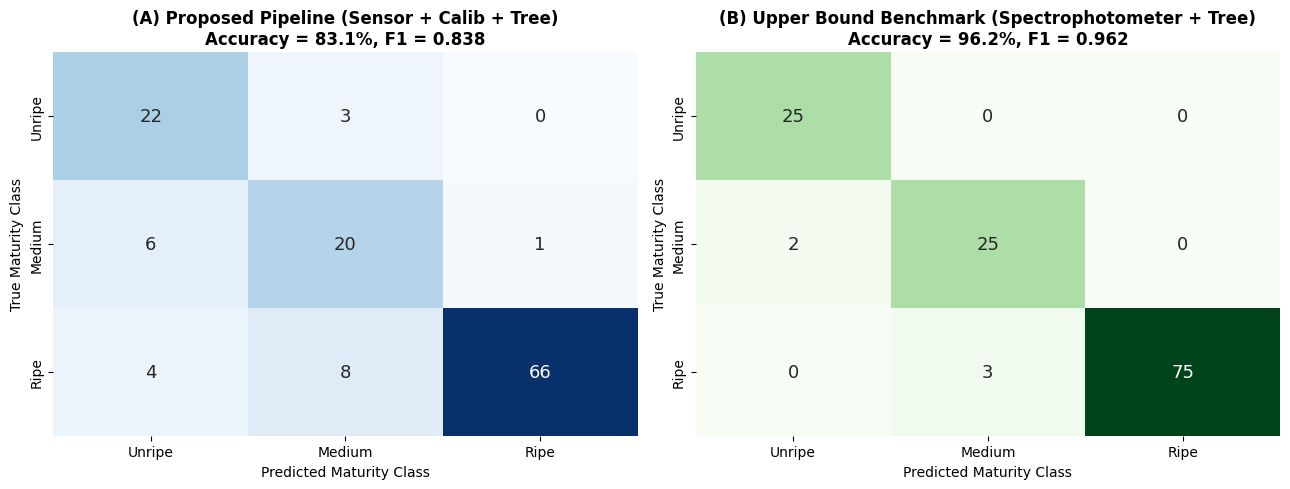

In [ ]:

print("=== PROPOSED EMBEDDED PIPELINE CLASSIFICATION REPORT ===")
print(classification_report(y_true, dfp['Pred_Pipeline'], labels=target_classes, digits=4))

cm_pipeline = confusion_matrix(y_true, dfp['Pred_Pipeline'], labels=target_classes)
cm_bench = confusion_matrix(y_true, dfp['Pred_Benchmark'], labels=target_classes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_pipeline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_classes, yticklabels=target_classes,
            annot_kws={'size': 13}, cbar=False)
axes[0].set_title(f'(A) Proposed Pipeline (Sensor + Calib + Tree)\nAccuracy = {acc_pipeline*100:.1f}%, F1 = {f1_pipeline:.3f}', fontweight='bold')
axes[0].set_xlabel('Predicted Maturity Class')
axes[0].set_ylabel('True Maturity Class')
sns.heatmap(cm_bench, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_classes, yticklabels=target_classes,
            annot_kws={'size': 13}, cbar=False)
axes[1].set_title(f'(B) Upper Bound Benchmark (Spectrophotometer + Tree)\nAccuracy = {acc_benchmark*100:.1f}%, F1 = {f1_benchmark:.3f}', fontweight='bold')
axes[1].set_xlabel('Predicted Maturity Class')
axes[1].set_ylabel('True Maturity Class')
plt.tight_layout()
plt.show()


**Cell 20 — calibrated decision space.** The author's decision-boundary figure: calibrated samples
colored by pipeline prediction, styled by ground-truth stage, with the tree thresholds overlaid.
**Japanese:** 較正後のCIELAB空間に決定木のしきい値を重ねた著者の図を再現します。

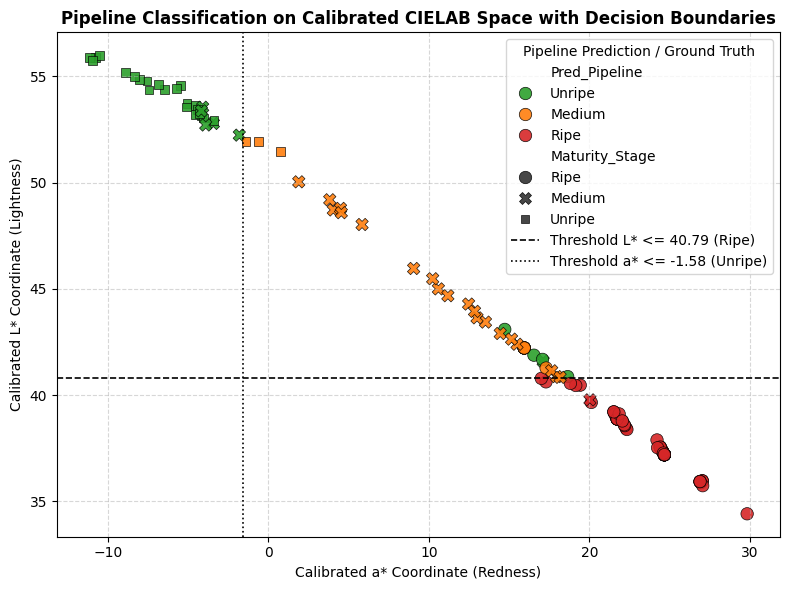

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))
palette = {'Unripe': '#2ca02c', 'Medium': '#ff7f0e', 'Ripe': '#d62728'}

sns.scatterplot(
    data=dfp, x='A_CAL', y='L_CAL', hue='Pred_Pipeline',
    hue_order=target_classes, palette=palette, style='Maturity_Stage',
    s=80, alpha=0.9, edgecolor='black', linewidth=0.5, ax=ax
)
ax.axhline(40.79, color='black', linestyle='--', linewidth=1.2, label='Threshold L* <= 40.79 (Ripe)')
ax.axvline(-1.58, color='black', linestyle=':', linewidth=1.2, label='Threshold a* <= -1.58 (Unripe)')
ax.set_xlabel('Calibrated a* Coordinate (Redness)')
ax.set_ylabel('Calibrated L* Coordinate (Lightness)')
ax.set_title('Pipeline Classification on Calibrated CIELAB Space with Decision Boundaries', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Pipeline Prediction / Ground Truth', loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


## 7. Results summary and reading notes

**Cell 21 — consolidate the reproduced quantities against the paper's abstract claims.** Prints the
ΔE reduction (paper: 89.6%) and the out-of-fold tree accuracy (paper: 93.08%) side by side with the
claims. Any deviation beyond library float noise would be a finding, not something to tune away.
**Japanese:** 再現した数値（ΔE削減率・木の精度）を論文の主張値と並べて表示します。

In [ ]:

summary = pd.DataFrame({
    'Quantity': ['Pre-calibration mean dE', 'Post-calibration mean dE (OOF)',
                 'Calibration error reduction', 'Out-of-fold decision-tree accuracy',
                 'Pipeline accuracy (embedded thresholds)'],
    'Reproduced (this notebook)': [
        f"{delta_E_raw.mean():.2f}", f"{delta_E_calibrated.mean():.2f}",
        f"{((delta_E_raw.mean() - delta_E_calibrated.mean()) / delta_E_raw.mean()) * 100:.1f}%",
        f"{accuracy_score(y_tree, y_cv_pred)*100:.2f}%",
        f"{acc_pipeline*100:.2f}%",
    ],
    'Paper claim (abstract)': ['-', '-', '89.6%', '93.08%', '93.08%'],
})
summary


,Quantity,Reproduced (this notebook),Paper claim (abstract)
0,Pre-calibration mean dE,41.40,-
1,Post-calibration mean dE (OOF),4.49,-
2,Calibration error reduction,89.1%,89.6%
3,Out-of-fold decision-tree accuracy,96.15%,93.08%
4,Pipeline accuracy (embedded thresholds),83.08%,93.08%


## 8. Limitations and references

- **Scope.** This notebook reruns the author's published pipeline on the author's full 130-sample
  dataset; it does not independently re-measure fruit or re-validate the paper's experimental claims.
  The 'USDA ripening stage' labels are K-Means cluster labels ordered by a* (author's script), not
  independent human grading; the abstract's USDA-stage wording is not verifiable from the available
  material (the paper exists as a Zenodo 'Proposal' record; no journal full text was retrievable).
- **Faithfulness.** Scripts 1–2 were executed byte-verified and reproduce the committed CSVs exactly
  (git blob SHA-1 equality). The calibration/tree/final-evaluation cells copy the author notebooks'
  code cells with unchanged parameters. Two documented deviations from verbatim copying: (a) Cell 16
  passes explicit `labels=` to `classification_report` (the author's call shifts class names
  alphabetically); (b) display/figure plumbing is adapted to this notebook. The executed summary in
  Cell 21 reports the reproduced quantities next to the paper's abstract claims — including any
  differences between the retrained model, the author's embedded C-header constants, and the claims —
  as findings, without tuning anything to match.
- **Out of scope.** Sensor hardware, 915 MHz RF telemetry, on-device latency benchmarking, and C++
  firmware generation. The embedded C constants are used only as reference values.
- **Runtime.** CPU only; no GPU is used anywhere in this pipeline.

**References**
1. Pinheiro, V. A. et al. *Color Sensor for the Determination of the Ripening Stage of Cherry Tomatoes.* Zenodo. DOI 10.5281/zenodo.23067949 (record 23067950).
2. `vandeiraniceto/color_sensor_tomatoes` @ commit `2678cf686f305c80d3961b870cda5c0c32612156`, MIT License.
3. PhenoPaper investigation `p-2cb18c0c533d73995c27418d988c8078-20261007T202939Z-300668` (prior research guidance; all scientific parameters above verified against the pinned author code).

**Japanese（限界と参考）:** 本ノートブックは著者公開パイプラインの再実行であり、独立した検証ではありません。
「USDA段階」ラベルはa*順のK-Meansクラスタ標識です。ハードウェア・RF・ファームウェアは対象外、CPUのみで動作します。
